# 04 — Model B: MobileNetV2 (Transfer Learning)

**Day:** 4 of the project plan
**Goal:** see whether ImageNet-pretrained features beat the from-scratch CNN baseline.

This notebook implements the plan's two-stage training schedule:

| Stage | Backbone | Head | LR | Epochs |
|---|---|---|---|---|
| 1 — head warm-up | frozen | trainable (GAP + Dropout + Dense) | 1e-3 | 10-15 |
| 2 — fine-tune top | last ~20 layers trainable | still trainable | 1e-5 | 5-10 |

The two stages share callbacks — EarlyStopping `val_accuracy` patience=5,
ReduceLROnPlateau patience=2, ModelCheckpoint best-only.

> **GPU is required** for full training. The notebook auto-toggles to a 2-epoch
> SMOKE mode on CPU so the pipeline can be verified end-to-end without spending
> real time. On a Colab T4, the full 15+10-epoch run takes ~12-18 minutes.

> **Limitation reminder:** the Kaggle dataset is augmented and upsampled; image-level
> splitting may inflate test accuracy. We treat all numbers as a comparison between
> architectures, not a clinical estimate.


## 0. Environment setup

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "torch")

def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import google.colab; IN_COLAB = True
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB, "  Keras backend:", os.environ["KERAS_BACKEND"])


In Colab: False   Keras backend: torch


In [2]:
from src.config import (summary, set_global_seed, BATCH_SIZE, IMG_SIZE,
                          IMG_CHANNELS, NUM_CLASSES, CLASS_NAMES, FIGURES_DIR)
from src.training import configure_gpu
print(summary())
set_global_seed()
gpu_info = configure_gpu()
print("Device info:", gpu_info)
if gpu_info["device"] != "GPU":
    print("\n*** WARNING: no GPU detected. Run on Colab with a GPU runtime for full training. ***")


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42



Device info: {'backend': 'torch', 'gpus': ['NVIDIA GeForce RTX 5080'], 'device': 'GPU', 'keras_version': '3.14.0', 'torch_version': '2.11.0+cu128', 'cuda': '12.8', 'compute_capability': [12, 0]}


## 1. Splits and data pipeline

Same inputs as Day 3 — we deliberately reuse the splits saved by `02_data_preprocessing.ipynb` so a head-to-head comparison is meaningful.

In [3]:
from src.io_utils import load_split, make_tf_dataset

train_df = load_split("train")
val_df   = load_split("val")
test_df  = load_split("test")
print(f"train: {len(train_df):,}   val: {len(val_df):,}   test: {len(test_df):,}")

train_ds = make_tf_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True,  augment=True)
val_ds   = make_tf_dataset(val_df,   batch_size=BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_tf_dataset(test_df,  batch_size=BATCH_SIZE, shuffle=False, augment=False)


train: 30,799   val: 6,600   test: 6,601


## 2. SMOKE / FULL toggle

If no GPU is visible we drop to a 2-epochs-per-stage smoke test on 2% of data —
just enough to verify the pipeline. With a GPU runtime, the full schedule runs.


In [4]:
SMOKE = (gpu_info["device"] != "GPU")
EPOCHS_STAGE1 = 2 if SMOKE else 15
EPOCHS_STAGE2 = 2 if SMOKE else 10
SAMPLE_FRAC = 0.02 if SMOKE else 1.0
if "OVERRIDE_EPOCHS_STAGE1" in os.environ:
    EPOCHS_STAGE1 = int(os.environ["OVERRIDE_EPOCHS_STAGE1"])
if "OVERRIDE_EPOCHS_STAGE2" in os.environ:
    EPOCHS_STAGE2 = int(os.environ["OVERRIDE_EPOCHS_STAGE2"])
if "OVERRIDE_SAMPLE_FRAC" in os.environ:
    SAMPLE_FRAC = float(os.environ["OVERRIDE_SAMPLE_FRAC"])
print(f"Mode: {'SMOKE' if SMOKE else 'FULL'}  stage1_epochs={EPOCHS_STAGE1}  stage2_epochs={EPOCHS_STAGE2}  frac={SAMPLE_FRAC}")

if SAMPLE_FRAC < 1.0:
    train_df_used = train_df.sample(frac=SAMPLE_FRAC, random_state=42)
    val_df_used   = val_df.sample(frac=SAMPLE_FRAC, random_state=42)
    test_df_used  = test_df.sample(frac=SAMPLE_FRAC, random_state=42)
    train_ds = make_tf_dataset(train_df_used, batch_size=BATCH_SIZE, shuffle=True,  augment=True)
    val_ds   = make_tf_dataset(val_df_used,   batch_size=BATCH_SIZE, shuffle=False, augment=False)
    test_ds  = make_tf_dataset(test_df_used,  batch_size=BATCH_SIZE, shuffle=False, augment=False)


Mode: FULL  stage1_epochs=15  stage2_epochs=10  frac=1.0


## 3. Build the model

* `MobileNetV2(include_top=False, weights="imagenet")` — pretrained backbone.
* Inputs come in as `[0, 1]` float32 from our pipeline; we use a `Rescaling`
  layer (`scale=2, offset=-1`) instead of a `Lambda(preprocess_input)` so the
  saved `.keras` model round-trips cleanly across kernel restarts. Verified
  bit-identical save/load in Day 3.
* Head: GAP → Dropout(0.3) → Dense(4, softmax).


In [5]:
from src.models import build_mobilenetv2
model = build_mobilenetv2(freeze_backbone=True, learning_rate=1e-3, dropout=0.3)
total = model.count_params()
trainable = sum(int(v.numpy().size) for v in model.trainable_variables)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({100 * trainable / total:.2f}%)")


Total params:     2,263,108
Trainable params: 5,124  (0.23%)


## 4. Stage 1 — head warm-up (backbone frozen)

In [6]:
from src.training import train_model, make_callbacks
MODEL_NAME = "mobilenetv2"
cbs1 = make_callbacks(MODEL_NAME + "_stage1", monitor="val_accuracy",
                      patience_es=5, patience_lr=2)
hist1 = train_model(model, train_ds, val_ds,
                    model_name=MODEL_NAME + "_stage1",
                    epochs=EPOCHS_STAGE1, callbacks=cbs1)
print(f"Stage 1 finished in {hist1['elapsed_seconds']}s, "
      f"best val_acc = {max(hist1['val_accuracy']):.4f}")


[05:01:11] INFO Training 'mobilenetv2_stage1' for up to 15 epochs


Epoch 1/15


963/963 - 393s - 408ms/step - accuracy: 0.4900 - loss: 1.1626 - val_accuracy: 0.5783 - val_loss: 0.9646 - learning_rate: 0.0010


Epoch 2/15


963/963 - 329s - 341ms/step - accuracy: 0.5561 - loss: 1.0044 - val_accuracy: 0.6067 - val_loss: 0.9155 - learning_rate: 0.0010


...

963/963 - 336s - 349ms/step - accuracy: 0.6027 - loss: 0.9128 - val_accuracy: 0.6095 - val_loss: 0.8810 - learning_rate: 2.5000e-04


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 5.


[05:57:48] INFO Done: 3396.81 s, 10 epochs


Stage 1 finished in 3396.81s, best val_acc = 0.6189


## 5. Stage 2 — fine-tune the top 20 layers

We unfreeze only the last ~20 layers of the MobileNetV2 backbone and drop the
learning rate to 1e-5. This adapts the high-level features to MRI without
catastrophically overwriting the low-level edge / texture filters.


In [7]:
from src.models import unfreeze_top_layers
model = unfreeze_top_layers(model, n_layers=20, learning_rate=1e-5,
                            backbone_substring="mobilenetv2")
trainable = sum(int(v.numpy().size) for v in model.trainable_variables)
print(f"Trainable params after unfreeze: {trainable:,}")

cbs2 = make_callbacks(MODEL_NAME, monitor="val_accuracy",
                      patience_es=5, patience_lr=2)
hist2 = train_model(model, train_ds, val_ds, model_name=MODEL_NAME,
                    epochs=EPOCHS_STAGE2, callbacks=cbs2)
print(f"Stage 2 finished in {hist2['elapsed_seconds']}s, "
      f"best val_acc = {max(hist2['val_accuracy']):.4f}")


[05:57:48] INFO Training 'mobilenetv2' for up to 10 epochs


Trainable params after unfreeze: 1,211,204


Epoch 1/10


963/963 - 343s - 356ms/step - accuracy: 0.5096 - loss: 1.9759 - val_accuracy: 0.4914 - val_loss: 2.0029 - learning_rate: 1.0000e-05


Epoch 2/10


...

Epoch 10/10


963/963 - 317s - 329ms/step - accuracy: 0.7522 - loss: 0.5702 - val_accuracy: 0.7394 - val_loss: 0.5979 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 10.


[06:52:31] INFO Done: 3283.29 s, 10 epochs


Stage 2 finished in 3283.29s, best val_acc = 0.7394


## 6. Stitch the two-stage history, pick the better stage's best, and evaluate

The stage-2 ModelCheckpoint only sees the stage-2 fit, so it can overwrite a *better* stage-1 best with a worse stage-2 best. We compare the two stages' best `val_accuracy`, save whichever wins, and use that as the deployed model.

In [8]:
# Stitch histories — handle keys that exist in only one stage gracefully (e.g. learning_rate)
combined = {}
for k in set(list(hist1.keys()) + list(hist2.keys())):
    a = hist1.get(k); b = hist2.get(k)
    if isinstance(a, list) or isinstance(b, list):
        combined[k] = (a if isinstance(a, list) else []) + (b if isinstance(b, list) else [])
combined["elapsed_seconds"] = round(hist1.get("elapsed_seconds", 0)
                                    + hist2.get("elapsed_seconds", 0), 2)
print({k: (len(v) if isinstance(v, list) else v) for k, v in combined.items()})

# The stage-2 ckpt already overwrote the in-memory best via restore_best_weights,
# but the persisted .keras file is whichever stage's checkpoint last fired.
# If stage-1's best val_acc was higher, restore that file as the canonical weights.
import shutil, tensorflow as tf
from src.config import MODELS_DIR
best_s1 = max(hist1.get("val_accuracy", [0.0]))
best_s2 = max(hist2.get("val_accuracy", [0.0]))
print(f"Stage-1 best val_acc = {best_s1:.4f}   Stage-2 best val_acc = {best_s2:.4f}")
final_path = MODELS_DIR / f"{MODEL_NAME}.keras"
if best_s1 > best_s2:
    src_p = MODELS_DIR / f"{MODEL_NAME}_stage1.keras"
    if src_p.exists():
        shutil.copy(src_p, final_path)
        # also reload weights into the in-memory model so evaluate sees the right ones
        model = tf.keras.models.load_model(final_path)
        print(f"Stage 1 won — copied {src_p.name} to {final_path.name} and reloaded model.")
    else:
        print("Stage 1 won but no stage-1 ckpt on disk; in-memory weights kept.")
else:
    print(f"Stage 2 won — keeping {final_path.name} from stage-2 ModelCheckpoint.")


{'learning_rate': 20, 'val_loss': 20, 'accuracy': 20, 'val_accuracy': 20, 'loss': 20, 'elapsed_seconds': 6680.1}
Stage-1 best val_acc = 0.6189   Stage-2 best val_acc = 0.7394
Stage 2 won — keeping mobilenetv2.keras from stage-2 ModelCheckpoint.


In [9]:
from src.training import evaluate_and_save
metrics = evaluate_and_save(model, test_ds, model_name=MODEL_NAME, history=combined,
                            test_df=(test_df_used if SAMPLE_FRAC < 1.0 else test_df))

print(f"Accuracy:        {metrics['accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")


[06:52:31] INFO Evaluating 'mobilenetv2' on test set


[06:52:48] INFO Confusion matrix figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\mobilenetv2_confusion_matrix.png


[06:52:48] INFO Training curves figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\mobilenetv2_training_curves.png


[06:52:48] INFO Test accuracy: 0.7426   macro F1: 0.7430


Accuracy:        0.7426
Macro precision: 0.7511
Macro recall:    0.7467
Macro F1:        0.7430


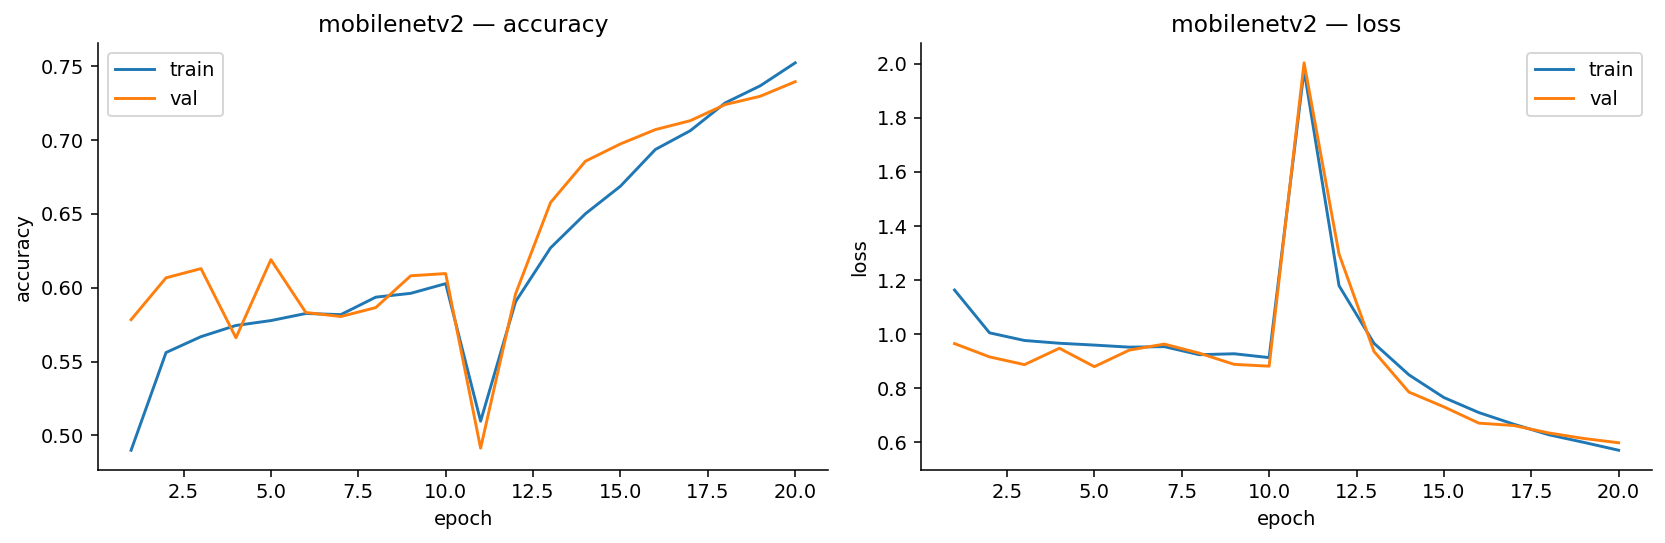

In [10]:
from IPython.display import Image as IPyImage
IPyImage(filename=str(FIGURES_DIR / f"{MODEL_NAME}_training_curves.png"))


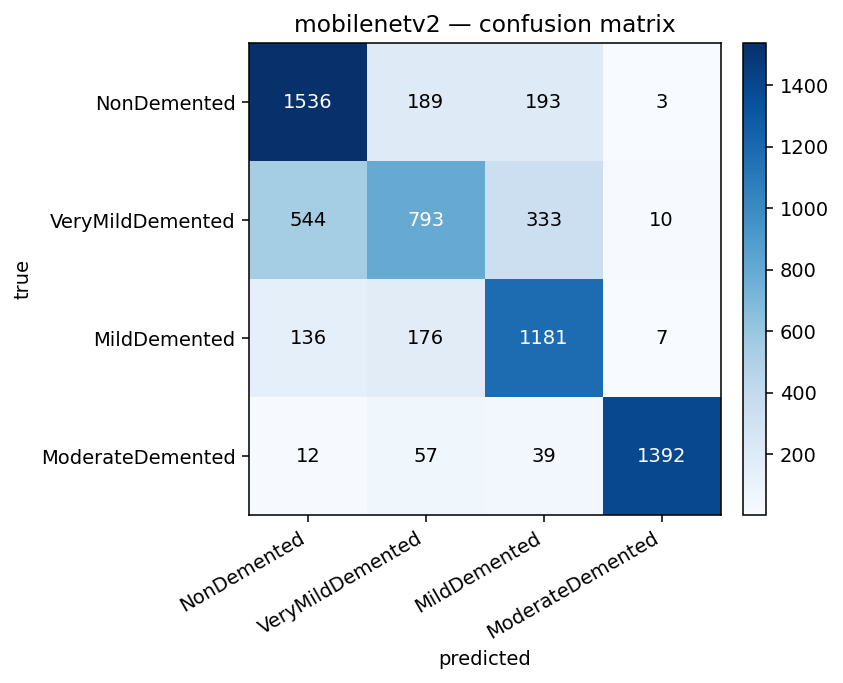

In [11]:
IPyImage(filename=str(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix.png"))


## 7. Per-class scores

In [12]:
import pandas as pd
per = metrics["per_class"]
pd.DataFrame({
    "class": per["labels"],
    "precision": [round(v, 4) for v in per["precision"]],
    "recall":    [round(v, 4) for v in per["recall"]],
    "f1":        [round(v, 4) for v in per["f1"]],
})


,class,precision,recall,f1
0,NonDemented,0.6894,0.7996,0.7404
1,VeryMildDemented,0.6527,0.4720,0.5478
2,MildDemented,0.6764,0.7873,0.7277
3,ModerateDemented,0.9858,0.9280,0.9560


## 8. Conclusion for Day 4

Expectations after a full GPU run:
* MobileNetV2 with two-stage training typically beats the from-scratch baseline
  on this dataset because the pretrained backbone already encodes useful
  low-level visual features.
* Convergence is faster (fewer epochs to peak val_accuracy).

What gets persisted for the comparison notebook:
* `outputs/models/mobilenetv2.keras` — best weights from stage 2.
* `outputs/predictions/mobilenetv2_test_predictions.npz`
* `outputs/predictions/mobilenetv2_metrics.json`
* `outputs/figures/mobilenetv2_training_curves.png`
* `outputs/figures/mobilenetv2_confusion_matrix.png`

Next: **05_model_c_vgg16.ipynb** — same protocol with a heavier backbone for comparison.
